In [2]:
import duckdb 
import pandas as pd
import numpy as np
from pathlib import Path

from scipy.stats import ks_2samp

import matplotlib.pyplot as plt
import seaborn as sns


final_conn = duckdb.connect('final_db')

In [20]:
def import_julia_validation_data():
    julia_validacao_path = Path('julia','Modelo Diário','test_data.csv')
    df_julia = pd.read_csv(julia_validacao_path)
    return df_julia

def import_mateus_validation_data(final_conn=final_conn):
    query = """
    SELECT
        vl_precipitacao_chirps AS valorchirps
        ,vl_irradiancia_allsky_power*86400/1000000 AS allsky_sfc_sw_dwn
        ,vl_pressao_nivel_superficie_power/1000 AS ps
        ,vl_umidade_relativa_2m_power AS rh2m
        ,vl_temperatura_media_2m_K_power-273.15 AS t2m
        ,vl_temperatura_maxima_2m_K_power-273.15 AS t2m_max
        ,vl_temperatura_minima_2m_K_power-273.15 AS t2m_min
        ,vl_temperatura_orvalho_2m_K_power-273.15 AS t2mdew
        ,vl_direcao_vento_2m_power AS wd2m
        ,vl_vento_medio_2m_power as ws2m
        ,vl_precipitacao_gpm_final_run AS valorsatelite
        ,latitude
        ,longitude
        ,vl_altitude AS elevacao
        ,vl_precipitacao AS valorestacao
        ,CASE WHEN MONTH(dt_medicao) = 1 THEN 1 ELSE 0 END AS data_mes_1
        ,CASE WHEN MONTH(dt_medicao) = 2 THEN 1 ELSE 0 END AS data_mes_2
        ,CASE WHEN MONTH(dt_medicao) = 3 THEN 1 ELSE 0 END AS data_mes_3
        ,CASE WHEN MONTH(dt_medicao) = 4 THEN 1 ELSE 0 END AS data_mes_4
        ,CASE WHEN MONTH(dt_medicao) = 5 THEN 1 ELSE 0 END AS data_mes_5
        ,CASE WHEN MONTH(dt_medicao) = 6 THEN 1 ELSE 0 END AS data_mes_6
        ,CASE WHEN MONTH(dt_medicao) = 7 THEN 1 ELSE 0 END AS data_mes_7
        ,CASE WHEN MONTH(dt_medicao) = 8 THEN 1 ELSE 0 END AS data_mes_8
        ,CASE WHEN MONTH(dt_medicao) = 9 THEN 1 ELSE 0 END AS data_mes_9
        ,CASE WHEN MONTH(dt_medicao) = 10 THEN 1 ELSE 0 END AS data_mes_10
        ,CASE WHEN MONTH(dt_medicao) = 11 THEN 1 ELSE 0 END AS data_mes_11
        ,CASE WHEN MONTH(dt_medicao) = 12 THEN 1 ELSE 0 END AS data_mes_12
    FROM abt_base
    WHERE 1=1
        AND percentil_temporal > 0.7
    """
    df_mateus = final_conn.execute(query).fetch_df()
    return df_mateus

In [16]:
df_julia = import_julia_validation_data()
df_mateus = import_mateus_validation_data()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [5]:
results = {}

numeric_cols = df_julia.select_dtypes(include=['number']).columns

for col in numeric_cols:
    statistic, p_value = ks_2samp(df_julia[col].dropna(), df_mateus[col].dropna())
    results[col] = statistic

df_diff = pd.Series(results).sort_values(ascending=False)

print("Colunas com maior diferença de distribuição (KS Statistic):")
print(df_diff.head(10))

coluna_maior_dif = df_diff.idxmax()
print(f"\nA coluna com a maior diferença é: {coluna_maior_dif} (KS = {df_diff.max():.4f})")

Colunas com maior diferença de distribuição (KS Statistic):
longitude        0.460855
elevacao         0.286466
latitude         0.283244
valorsatelite    0.236941
ps               0.211002
wd2m             0.156452
ws2m             0.144988
t2m_min          0.108663
t2mdew           0.094342
rh2m             0.063896
dtype: float64

A coluna com a maior diferença é: longitude (KS = 0.4609)


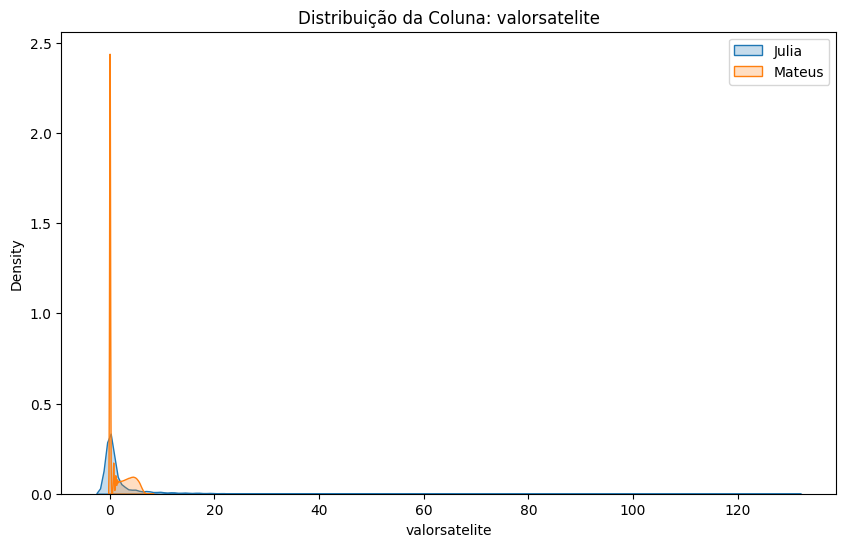

In [22]:
# col = coluna_maior_dif
col = 'valorsatelite'

plt.figure(figsize=(10, 6))
sns.kdeplot(df_julia[col], label='Julia', fill=True)
sns.kdeplot(np.log(df_mateus[col]+1), label='Mateus', fill=True)
plt.title(f'Distribuição da Coluna: {col}')
plt.legend()
plt.show()

In [23]:
column = 'valorsatelite'

print(df_julia[column].describe())
print()
print(np.log(df_mateus[column]+1).describe())

count    68620.000000
mean         2.987385
std          7.736589
min          0.000000
25%          0.000000
50%          0.000000
75%          2.400000
max        129.600000
Name: valorsatelite, dtype: float64

count    5.445084e+06
mean     1.512550e+00
std      1.993838e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      3.135494e+00
max      8.158516e+00
Name: valorsatelite, dtype: float64


In [19]:
df_mateus.loc[df_mateus['valorsatelite']>=1000,['valorchirps','valorsatelite']]

,valorchirps,valorsatelite
305,0.000000,1241.0
521,15.060000,1518.0
961,0.000000,1013.0
1554,0.000000,1302.0
2442,0.000000,1498.0
...,...,...
5443985,36.790001,1219.0
5444400,20.980000,1142.0
5444681,0.000000,1353.0
5444761,0.000000,1381.0
